In [11]:
# RRCP (02/08/2026): Notebook de Evaluación del Modelo
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

In [5]:
# Cargar los datos
df_partidos = pd.read_csv("../data/partidos_cebollitas_30072026.csv")
df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']

# Variables independientes
X = df_partidos[['posesion_local (%)', 'tiros_arco_local']]
# Variable dependiente
y = df_partidos['diferencia_goles']

# Dividir el conjunto de datos en dos partes:
#   Parte 1: 80% para entrenar el modelo (X_train, y_train)
#   Parte 2: 20% para evaluar el modelo (X_test, y_test)
# Sin embargo, antes de hacer esa división, mezcla aleatoriamente los registros.
# random_state fija la semilla (seed) del generador de número aleatorios y al asignar 42
# especifica que usará siempre la misma secuencia de número aleatorios. Usar 42 es una tradición en programación.
# Esto garantiza que cada vez ue se ejecute el programa la mezcla de datos de prueba y entrenamiento sea la misma.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo_rl = LinearRegression()
modelo_rl.fit(X_train, y_train)

y_pred = modelo_rl.predict(X_test)

### Calculo de los Errores

In [6]:
# Calculo de Métricas
mse = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE (Error Cuadrático Medio): {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
print(f"MAE (Error Absoluto Medio): {mae:2f}")
print(f"R2 (Coeficiente de Determinación): {r2:.2f}")

MSE (Error Cuadrático Medio): 1.89
RMSE (Raíz del Error Cuadrático Medio): 1.37
MAE (Error Absoluto Medio): 1.885208
R2 (Coeficiente de Determinación): -0.03


### Interpretación Rapída:
- MSE/RMSE: Cuanto más cerca de 0, mejor. Indica cuánto se alejan las predicciones.
- MAE: Error promedio en goles. Fácil de entender. Un MAE de 0.8 -> error promedio de 0.8 goles.
- R2: Cúanto explica el modelo del comportamiento real. 1 es perfecto, 0 es como adivinar.

Notas: 
- MAE = 1.98. En promedio, estamos fallando por casi 2 goles por cada predicción.
- R2 = -0.03. El modelo no está explicando nada de la variabilidad en los datos. Esta peor que si simplemente predijeramos el promedio en todos los casos.

Todo esto nos dice que el modelo no está prediciendo bien, y necesitamos revsiar los datos, las variables e incluso el tipo de modelo que estamos usando.


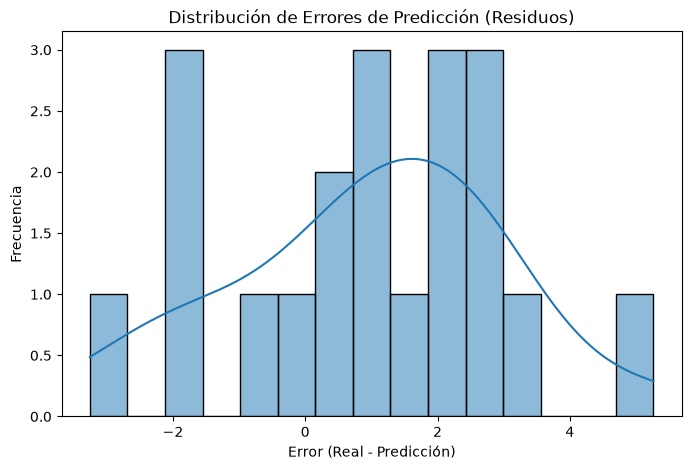

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(y_test - y_pred, bins = 15, kde = True)
plt.title("Distribución de Errores de Predicción (Residuos)")
plt.xlabel('Error (Real - Predicción)')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
# ¿Como se interpreta el umbral?
#
def evaluar_prediccion(threshold_mae):
    calidad = "buena" if mae <= threshold_mae else "regular o mala"
    print(f"Tu modelo tiene una MAE de {mae:.2f}, considerar {calidad} (umbral definido: {threshold_mae})")

umbral_widget = widgets.FloatSlider(min = 0.1, max = 5, step = 0.1, value = 1.0, description = 'Umbral MAE: ')
widgets.interactive(evaluar_prediccion, threshold_mae = umbral_widget)

interactive(children=(FloatSlider(value=1.0, description='Umbral MAE: ', max=5.0, min=0.1), Output()), _dom_cl…